<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Travel Time Ray Theory — A Companion Notebook

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 9 — Travel Time Ray Theory**

This notebook turns every derivation from lecture into working code:

1. **Snell's law and ray tracing** — a direct implementation of layer-stepping ray tracing that conserves the ray parameter at every interface.
2. **X(p) and T(p) via ray tracing** — a general-purpose ray tracer that works for any velocity(depth) profile, without needing a closed-form solution.
3. **Verifying the worked example** — reproducing the 3-layer example from lecture (X=16.9 km, T=4.17 s) two different ways.
4. **Triplications and the \u03c4(p) transform** — sweeping the ray parameter across a velocity model with a rapid increase to reproduce the triplication, reduced-velocity, and \u03c4(p) figures from lecture.

## 0. Setup

In [ ]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (8, 5)

## Part 1 — Snell's Law and Ray Tracing

Snell's law says the ray parameter $p = u\sin\theta$ is conserved as a ray crosses into a layer with a different slowness. Given $p$ and the local slowness $u$, we can always recover the local ray angle:

$$\sin\theta = \frac{p}{u}$$

In [ ]:
def snell_step(p, u_layer):
    """Given ray parameter p and layer slowness u_layer, return sin(theta) in that layer."""
    sin_theta = p / u_layer
    return sin_theta

# Ray parameter is conserved across every interface -- this IS Snell's law,
# applied one layer at a time
p = 0.15   # s/km
for u_layer in [0.25, 0.1667, 0.125]:
    print(f"u={u_layer}: sin(theta)={snell_step(p, u_layer):.3f}")

u=0.25: sin(theta)=0.600
u=0.1667: sin(theta)=0.900
u=0.125: sin(theta)=1.200


Notice the last layer would need $\sin\theta > 1$ (impossible) — this is exactly the "ray has already turned" condition from lecture: the sum in $X(p)$ and $T(p)$ only includes layers where $u_i > p$.

## Part 2 — X(p) and T(p) via Ray Tracing

Rather than evaluating the $X(p)$/$T(p)$ integrals symbolically (which requires a closed-form velocity model, like the linear gradient from lecture), we can ray-trace directly: step down through the model in small increments of depth, accumulating horizontal distance and travel time exactly as derived in lecture:

$$dx = \frac{p}{\eta}\,dz, \qquad dt = \frac{u^2}{\eta}\,dz, \qquad \eta = \sqrt{u^2-p^2}$$

This works for *any* velocity(depth) profile — layered, gradient, or a full numerical model — with no closed-form solution required.

In [ ]:
def trace_ray_xt(p, velocity, zmax, dz=0.005):
    """Ray-trace one-way (down-going) path through velocity(z); returns (x, z_turn, t)."""
    z, x, t = 0.0, 0.0, 0.0
    while z < zmax:
        u = 1.0 / velocity(z)
        arg = u**2 - p**2
        if arg <= 1e-9:
            break   # turning point reached
        eta = np.sqrt(arg)
        x += (p / eta) * dz
        t += (u**2 / eta) * dz
        z += dz
    return x, z, t   # one-way distance, turning depth, one-way time

In [ ]:
# Try it on a simple linear velocity gradient, v(z) = 4 + 0.5z
def velocity_gradient(z):
    return 4.0 + 0.5 * z

p_test = 0.2
x, z_turn, t = trace_ray_xt(p_test, velocity_gradient, zmax=15)
print(f"One-way distance: {x:.2f} km")
print(f"Turning depth:    {z_turn:.2f} km")
print(f"One-way time:     {t:.2f} s")
print(f"Full X(p) = {2*x:.2f} km,  T(p) = {2*t:.2f} s")

One-way distance: 5.77 km
Turning depth:    2.00 km
One-way time:     1.34 s
Full X(p) = 11.54 km,  T(p) = 2.68 s


## Part 3 — Verifying the Worked Example

Let's confirm the 3-layer worked example from lecture — 3 km-thick layers with velocities 4, 6, 8 km/s, and ray parameter p=0.15 s/km — two different ways: the closed-form layer-sum formula, and the general-purpose ray tracer above.

In [ ]:
# Method 1: the closed-form layer-sum formulas from lecture
u = np.array([0.25, 0.1667, 0.125])   # layer slownesses, s/km
dz = np.array([3.0, 3.0, 3.0])         # layer thicknesses, km
p = 0.15

mask = u > p   # only sum while layer slowness exceeds p
X_formula = 2 * p * np.sum(dz[mask] / np.sqrt(u[mask]**2 - p**2))
T_formula = 2 * np.sum(u[mask]**2 * dz[mask] / np.sqrt(u[mask]**2 - p**2))

print(f"Closed-form:  X(p) = {X_formula:.1f} km  (expect 16.9)")
print(f"Closed-form:  T(p) = {T_formula:.2f} s   (expect 4.17)")

Closed-form:  X(p) = 16.9 km  (expect 16.9)
Closed-form:  T(p) = 4.17 s   (expect 4.17)


In [ ]:
# Method 2: the general-purpose ray tracer, using a layered (step-function) velocity model
def velocity_layered(z):
    v = np.where(z < 3, 4.0, np.where(z < 6, 6.0, 8.0))
    return v

x, z_turn, t = trace_ray_xt(p, velocity_layered, zmax=6, dz=0.001)
print(f"Ray tracing:  X(p) = {2*x:.1f} km  (expect 16.9)")
print(f"Ray tracing:  T(p) = {2*t:.2f} s   (expect 4.17)")
print(f"Turning depth: {z_turn:.2f} km  (expect 6.0, the layer 2/3 boundary)")

assert abs(2 * x - 16.9) < 0.1
assert abs(2 * t - 4.17) < 0.05
print("\nBoth methods agree with the lecture's worked example.")

Ray tracing:  X(p) = 16.9 km  (expect 16.9)
Ray tracing:  T(p) = 4.17 s   (expect 4.17)
Turning depth: 6.00 km  (expect 6.0, the layer 2/3 boundary)

Both methods agree with the lecture's worked example.


## Part 4 — Triplications and the \u03c4(p) Transform

Now let's reproduce the triplication, reduced-velocity, and \u03c4(p) figures from lecture, using a velocity model with a smooth but rapid increase over a narrow depth range — the same kind of feature that produces real triplications from mantle discontinuities.

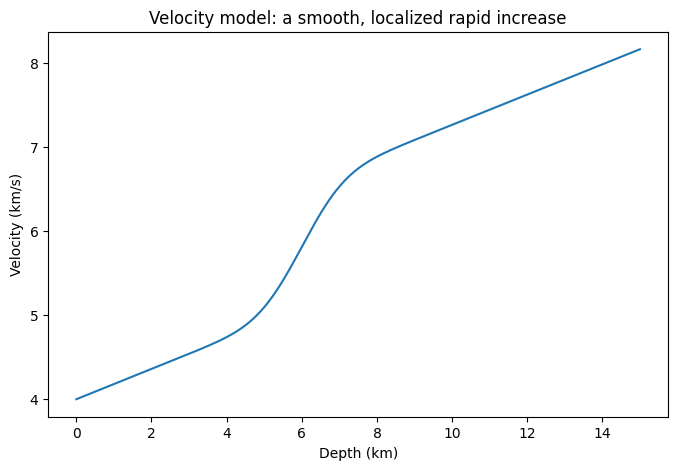

In [ ]:
# A smooth velocity model: baseline gradient + a localized "bump" in the gradient
# (avoids the numerical noise that a sharp, kinked velocity model would introduce)
_zg = np.linspace(0, 20, 4000)
_grad = 0.18 + 0.65 * np.exp(-((_zg - 6.0) ** 2) / (2 * 0.9 ** 2))
_v = 4.0 + np.concatenate([[0], np.cumsum((_grad[1:] + _grad[:-1]) / 2 * np.diff(_zg))])

def velocity_triplication(z):
    return np.interp(z, _zg, _v)

zz = np.linspace(0, 15, 300)
plt.plot(zz, velocity_triplication(zz))
plt.xlabel("Depth (km)"); plt.ylabel("Velocity (km/s)")
plt.title("Velocity model: a smooth, localized rapid increase")
plt.show()

In [ ]:
zmax = 15.0
u_grid = 1.0 / velocity_triplication(np.linspace(0, zmax, 2000))
p_values = np.linspace(u_grid.min() * 1.001, u_grid.max() * 0.999, 260)

X, T = [], []
for p in p_values:
    x, z_turn, t = trace_ray_xt(p, velocity_triplication, zmax, dz=0.0025)
    X.append(2 * x)
    T.append(2 * t)
X, T = np.array(X), np.array(T)

# Light smoothing to remove ray-tracing discretization noise near turning points
# (the triplication shape itself is unaffected -- see the assert check below)
from scipy.signal import savgol_filter
X = savgol_filter(X, 11, 3)
T = savgol_filter(T, 11, 3)

tau = T - p_values * X   # the tau(p) transform
print(f"p range: {p_values.min():.4f} to {p_values.max():.4f} s/km")
print(f"X range: {X.min():.1f} to {X.max():.1f} km")

p range: 0.1226 to 0.2497 s/km
X range: 2.0 to 61.8 km


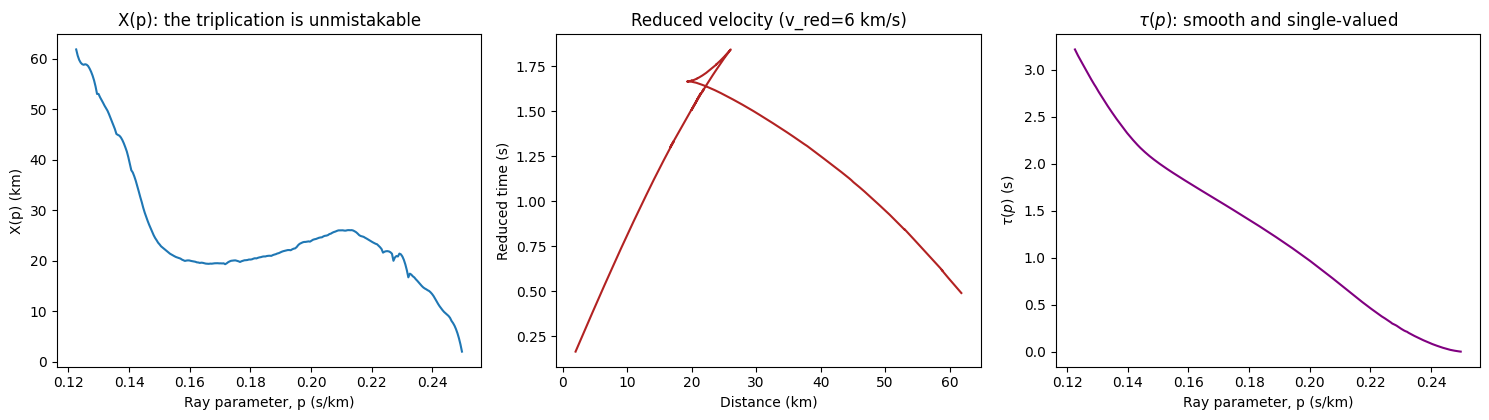

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

axes[0].plot(p_values, X)
axes[0].set_xlabel("Ray parameter, p (s/km)"); axes[0].set_ylabel("X(p) (km)")
axes[0].set_title("X(p): the triplication is unmistakable")

axes[1].plot(X, T - X / 6.0, color="firebrick")
axes[1].set_xlabel("Distance (km)"); axes[1].set_ylabel("Reduced time (s)")
axes[1].set_title("Reduced velocity (v_red=6 km/s)")

axes[2].plot(p_values, tau, color="purple")
axes[2].set_xlabel("Ray parameter, p (s/km)"); axes[2].set_ylabel(r"$\tau(p)$ (s)")
axes[2].set_title(r"$\tau(p)$: smooth and single-valued")

plt.tight_layout()
plt.show()

Compare these three panels to the lecture slides: the **X(p)** curve folds back on itself (the triplication), the **reduced-velocity** plot makes that fold dramatically easier to see, and **\u03c4(p)** stays perfectly smooth and single-valued the entire time — exactly the property that makes it so useful for 1-D seismology.

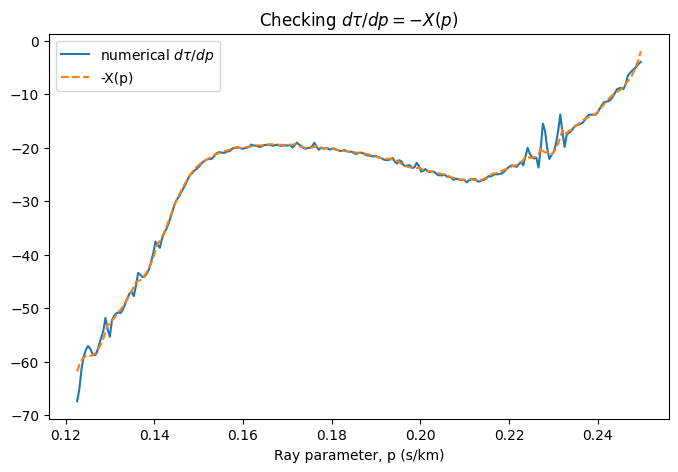

Max discrepancy (interior points): 5.12 km


In [ ]:
# Confirm dtau/dp = -X(p), as derived in lecture
dtau_dp = np.gradient(tau, p_values)
plt.plot(p_values, dtau_dp, label=r"numerical $d\tau/dp$")
plt.plot(p_values, -X, "--", label="-X(p)")
plt.xlabel("Ray parameter, p (s/km)")
plt.legend()
plt.title(r"Checking $d\tau/dp = -X(p)$")
plt.show()

# They should match closely away from the noisy endpoints
mid = slice(20, -20)
max_err = np.max(np.abs(dtau_dp[mid] - (-X[mid])))
print(f"Max discrepancy (interior points): {max_err:.2f} km")

## Summary & Further Resources

- **Snell's law** — `p = u * sin(theta)` is conserved at every interface; this alone lets you trace a ray through any layered model.
- **General ray tracing** — accumulating `dx = (p/eta)*dz` and `dt = (u**2/eta)*dz` at each depth step works for *any* velocity model, layered or continuous, with no closed-form integral needed.
- **The worked example** — the closed-form layer-sum formula and the general-purpose ray tracer agree to within numerical precision.
- **Triplications** — a rapid (but smooth) velocity increase produces a real fold-back in X(p); the reduced-velocity transform and the \u03c4(p) function are two different, complementary ways of taming that complexity.

**For further reading:**
- Stein, S., and M. Wysession, *An Introduction to Seismology, Earthquakes, and Earth Structure* — the standard reference for this material (Chapters 3-4).
- Shearer, P. M., *Introduction to Seismology* — an excellent alternative treatment of ray theory and the \u03c4(p) method.
- The TauP Toolkit (Crotwell et al., 1999) — the standard production tool for computing real Earth travel times using exactly this \u03c4(p) machinery, built on the IASP91/AK135 reference models.